In [1]:
from typing import TypedDict, List, Optional, Dict, Any
import json
from langchain_ollama import ChatOllama
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, END

In [3]:
# Setting up the state - memory of the system

class AgentState(TypedDict):
    # input
    blog_title:str
    blog_content:str

    # intermediate - output
    tags:List[str]
    summary:str

    # iterations metadata
    count: int
    max_iter: int
    violations: List[str]
    re_run: bool
    
    # final output
    final: Dict[str, Any]

In [5]:
# Prompt templates for Planner, Reviewer and Finalizer

planner_prompt_template = """
You are a helpful assistant. Please follow ALL the instructions given below.
1. Generate EXACTLY THREE topical tags based on blog_title and blog_content. The three tags should be different from each other. 
2. Generate a one-sentence summary of blog_content in <= 25 words. You are strictly PROHIBITED from using blog_title for generating summary. The summary should be meaningful and cover all aspects of the blog_content.
3. Output valid JSON with exactly two keys: "summary" and "tags". No extra keys, no extra text.

blog_title: {blog_title}
blog_content: {blog_content}
"""

reviewer_prompt_template = """
You are an instruction-following model. 
Your ONLY task is to update the summary and tags according to strict rules.

Follow these rules EXACTLY:

RULES FOR SUMMARY:
- If the provided summary has 25 words or fewer, use it unchanged.
- If it has more than 25 words, generate a NEW one-sentence summary using ONLY the blog_content.
- The final summary MUST be 25 words or fewer.

RULES FOR TAGS:
- If the provided tags list contains EXACTLY 3 tags, use them unchanged.
- If it contains any number other than 3, generate EXACTLY 3 new topical tags using blog_content and blog_title.
- Tags must be single words or short phrases (no sentences).

OUTPUT FORMAT (MANDATORY):
- Output ONLY valid JSON.
- JSON must contain EXACTLY these two keys:
  "updated_summary"
  "updated_tags"
- No explanations, no extra text, no commentary.

INPUT:
summary: {summary}
tags: {tags}
blog_title: {blog_title}
blog_content: {blog_content}

Now produce the JSON output.
"""

finalizer_prompt_template = """You are an instruction-following model. 
Your ONLY task is to CLEAN the tags and summary according to strict rules.

Follow these rules EXACTLY:

TAG CLEANING RULES:
- Replace every underscore (_) with a space in the tags.
- Do not change anything else.

SUMMARY CLEANING RULES:
- If the provided summary has no special characters apart from space, hyphen, period, comma and semicolon, use it UNCHANGED.
- If it has any other special characters, remove them.
- DO NOT change the wording of the summary, except for removing invalid special characters.

OUTPUT FORMAT (MANDATORY):
- Output ONLY valid JSON.
- JSON must contain EXACTLY these two keys:
  "tags"
  "summary"
- No explanations, no extra text, no commentary.

INPUT:
tags: {tags}
summary: {summary}

Now produce the JSON output.
"""

In [7]:
# Defining tools for validation
def numOfTags(tags):
    """"Tool to count the number of tags"""
    return len(tags)

def numWordsInSummary(summary):
    """"Tool to count number of words in the summary"""
    return len([w for w in summary.split(" ") if w])



In [9]:
# Defining LLM
# llm = ChatOllama(
#             model = "smollm:1.7b",
#             temperature = 0,
#             seed = 45,
#             format = "json"
#             )


llm = ChatOllama(
            model = "llama3.2:latest",
            temperature = 0,
            seed = 12,
            verbose = True,
            format = "json"
        )

In [11]:
# Defining nodes

# Planner node

def planner_node(state:AgentState):
    """ The planner agents generates tags and summary for a given blog title and content."""
    
    # Creating Planner Agent LLM chain
    planner_prompt = ChatPromptTemplate.from_template(planner_prompt_template)
    planner_llm_chain = planner_prompt | llm
    planner_output = planner_llm_chain.invoke({"blog_title":state["blog_title"], "blog_content":state["blog_content"]})
    # extracting JSON from output 
    planner_response = planner_output.content
    
    # Extracting JSON from string
    planner_response = json.loads(planner_response)
    
    # Extracting summary and tags
    summary = planner_response["summary"]
    tags = planner_response["tags"]
    
    return {
        "tags": tags,
        "summary": summary
    }

In [31]:
# Reviewer Node

def reviewer_node(state:AgentState):

    """ The reviewer agent reviews the summary and tags generated by planner agent"""
    
    # Reviewer LLM chain
    reviewer_prompt = ChatPromptTemplate.from_template(reviewer_prompt_template)
    reviewer_llm_chain = reviewer_prompt | llm
    reviewer_output = reviewer_llm_chain.invoke({"summary":state["summary"], "tags":state["tags"], "blog_title":state["blog_title"], "blog_content":state["blog_content"]})
    
    # extracting JSON from output
    reviewer_response  = reviewer_output.content
    
    # Extracting JSON from string
    reviewer_response = json.loads(reviewer_response)

    updated_tags = reviewer_response["updated_tags"]
    updated_summary = reviewer_response["updated_summary"]

    # using tools to validate the output

    tag_count = numOfTags(updated_tags)
    summary_word_count = numWordsInSummary(updated_summary)

    # Based on the tools output, deciding on violations to re-run the flow

    violations = []
    if tag_count != 3:
        violations.append(f"expected 3 tags, but got {tag_count}")
    if summary_word_count > 25:
        violations.append(f"summary is too long with {summary_word_count} number of words")

    re_run = len(violations) > 0

    #-- uncomment below to test correction loop
    # # # temporarily setting to set issue everytime
    # violations = ["foreced issue for testing"]
    # re_run = True
    
    return {
        "tags": updated_tags,
        "summary": updated_summary,
        "violations": violations,
        "re_run": re_run,
        "count":state.get("count", 0)+(1 if re_run else 0)
    }

    ## -- uncomment below to test correction loop
    
    # return {
    #     "tags": updated_tags,
    #     "summary": updated_summary,
    #     "violations": violations,
    #     "re_run": re_run,
    #     "count":state.get("count", 0)+ 1
    # }

In [15]:
# Finalizer Node

def finalizer_node(state:AgentState):
    """The finalizer generates the final cleaned tags and summary for the given blog title and content."""
    # Finalizer LLM chain
    finalizer_prompt = ChatPromptTemplate.from_template(finalizer_prompt_template)
    finalizer_llm_chain = finalizer_prompt | llm
    finalizer_output = finalizer_llm_chain.invoke({"tags":state["tags"], "summary":state["summary"]})
    
    # extracting JSON from output
    finalizer_response  = finalizer_output.content
    
    # Extracting JSON from string
    finalizer_response = json.loads(finalizer_response)
    
    return {
        "final": finalizer_response
    }

In [17]:
# # Building the supervisor - not in use

# def supervisor_node(state:AgentState):

#     """"Its role is to choose next node: planner, reviewer or finalizer"""
#     count = state.get("count", 0) # checking for the key  "count" in state, if present then use its value, else use 0 as default value
#     max_iter = state.get("max_iter", 3) # checking for the key  "max_iter" in state, if present then use its value, else use 3 as default value

#     # If re-run is required
#     if state.get("re_run", False):
#         if count >= max_iter:
#             return "finalizer"
#         return "planner"
        
#     # If output is not reviewed at least once
#     if "violations" not in state:
#         return "reviewer"

#     # If violations still exists
#     if state.get("violations", []):
#         if count >= max_iter:
#             return "finalizer"
#         return "planner"
#     # if everything is valid
#     return "finalizer"
            


**Supervisor node - routing and updating session state with counter**

In [19]:
def route_after_planner(state: AgentState):
    return "reviewer"

In [21]:
def route_after_reviewer(state: AgentState):
    count = state.get("count", 0)
    max_iter = state.get("max_iter", 3)

    if state.get("re_run", False):
        if count >= max_iter:
            return "finalizer"
        return "planner"

    return "finalizer"


In [ ]:
# not in use
# graph.add_conditional_edges("planner", supervisor_node, {"reviewer":"reviewer", "planner":"planner", "finalizer":"finalizer", "end": END})
# graph.add_conditional_edges("reviewer", supervisor_node, {"reviewer":"reviewer", "planner":"planner", "finalizer":"finalizer", "end": END})

In [33]:
# Building graph

graph = StateGraph(AgentState)

#adding nodes
graph.add_node("planner", planner_node)
graph.add_node("reviewer", reviewer_node)
graph.add_node("finalizer", finalizer_node)

# entry point
graph.set_entry_point("planner")

#adding edges
graph.add_conditional_edges(
    "planner",
    route_after_planner,
    {"reviewer": "reviewer"},
)

graph.add_conditional_edges(
    "reviewer",
    route_after_reviewer,
    {"planner": "planner", "finalizer": "finalizer"},
)

graph.add_edge("finalizer", END)

app = graph.compile()

In [35]:
blog_title = "Why Reading Still Matters in the Digital Age"
blog_content = (
    "Despite the rise of short-form content and social media, reading remains a powerful habit. "
    "Books encourage deep thinking, improve vocabulary, and strengthen concentration. Unlike quick online scrolling, reading allows ideas to unfold gradually, helping readers develop patience and critical thinking. Whether fiction or non-fiction, reading exposes us to new perspectives and experiences, making it a timeless tool for personal growth."
)


In [27]:
# blog_title = "Why Python Remains the Go-To Language for Data Science"

# blog_content = """
# Python continues to dominate the data science ecosystem, and for good reason. Its simple, readable syntax lowers the barrier to entry, allowing analysts and engineers to focus more on solving problems than wrestling with code. A rich ecosystem of libraries—such as NumPy, Pandas, Matplotlib, and Scikit-learn—covers the entire data workflow, from data cleaning to model deployment.

# Beyond libraries, Python integrates seamlessly with big data tools, cloud platforms, and production systems, making it suitable for both experimentation and real-world applications. Strong community support ensures continuous improvement, extensive documentation, and rapid troubleshooting.

# Whether you’re building dashboards, training machine learning models, or automating data pipelines, Python offers the flexibility and scalability needed to turn data into actionable insights.


# """

In [37]:
# Defining initial state
initial_state: AgentState = {
        "blog_title": blog_title,
        "blog_content": blog_content,
        "count": 0,
        "max_iter": 3,
    }

In [29]:
for step in app.stream(initial_state):
    print(step)

{'planner': {'tags': ['Digital Literacy', 'Cognitive Development', 'Personal Growth'], 'summary': 'Reading fosters deep thinking, improves vocabulary, and strengthens concentration, offering a gradual exposure to new ideas and promoting personal growth.'}}
{'reviewer': {'tags': ['Critical Thinking', 'Personal Development', 'Knowledge Acquisition'], 'summary': 'Reading fosters deep thinking and promotes personal growth.', 'violations': [], 're_run': False, 'count': 0}}
{'finalizer': {'final': {'tags': [' Critical Thinking ', ' Personal Development ', ' Knowledge Acquisition '], 'summary': 'Reading fosters deep thinking and promotes personal growth.'}}}


# testing correction loop

In [39]:
for step in app.stream(initial_state):
    print(step)

{'planner': {'tags': ['Digital Literacy', 'Cognitive Development', 'Personal Growth'], 'summary': 'Reading fosters deep thinking, improves vocabulary, and strengthens concentration, offering a gradual exposure to new ideas and promoting personal growth.'}}
{'reviewer': {'tags': ['Critical Thinking', 'Personal Development', 'Knowledge Acquisition'], 'summary': 'Reading fosters deep thinking and promotes personal growth.', 'violations': ['foreced issue for testing'], 're_run': True, 'count': 1}}
{'planner': {'tags': ['Digital Literacy', 'Cognitive Development', 'Personal Growth'], 'summary': 'Reading fosters deep thinking, improves vocabulary, and strengthens concentration, offering a gradual exposure to new ideas and promoting personal growth.'}}
{'reviewer': {'tags': ['Critical Thinking', 'Personal Development', 'Knowledge Acquisition'], 'summary': 'Reading fosters deep thinking and promotes personal growth.', 'violations': ['foreced issue for testing'], 're_run': True, 'count': 2}}
{'

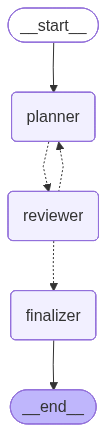

In [89]:
from IPython.display import Image, display
Image(app.get_graph().draw_mermaid_png())